# Discriminant Validity Analysis: Sensitivity vs CaseAlign (Tabular Data)

This notebook performs discriminant validity analysis for XAI metrics on **tabular data** by computing neighbourhood explanation coherence and fitting nested OLS regression models:

- **Neighbourhood Coherence**: Measures how consistently explanation similarities align with input feature similarities in same-class neighbourhoods
- **Model 1**: coherence ~ sensitivity
- **Model 2**: coherence ~ sensitivity + CaseAlign

The analysis tests whether CaseAlign explains additional variance in explanation coherence beyond sensitivity alone.

## Usage Instructions

This notebook now uses the **same data-loading path** as `case_align_correlation_analysis.ipynb`.

### Data Loading Flow

- It calls `run_correlation_experiment(...)` from `src/experiments/correlation_analysis.py`
- That function loads model + dataset, computes explanations, then returns a DataFrame with:
  - `captum_sensitivity`
  - `case_align_S_plus`
  - `case_align_R_bounded`
  - `knn_similarity_robustness`
  - `class`, `index`

### What to configure

In **Cell 4**, set:
- `DATASET` (e.g., `adult`, `heloc`, `bank`, `cancer`, `wine`, `beans`)
- `N_SAMPLES`, `K_NEIGHBOURS`, `EPSILON`, `SIMILARITY_METRIC`
- `CASEALIGN_COLUMN` (usually `case_align_R_bounded`)
- `COHERENCE_COLUMN` (usually `knn_similarity_robustness`)

### Output

Results are saved to `src/results/tabular_discriminant_validity_analysis/`:
- `discriminant_validity_analysis.png`
- `diagnostic_plots.png`
- `analysis_summary.json`
- `regression_data.csv`
- `regression_details.txt`

In [28]:
# Imports
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

current_dir = Path.cwd()
if current_dir.name == "experiments":
    SRC_DIR = current_dir.parent
elif (current_dir / "src").exists():
    SRC_DIR = current_dir / "src"
else:
    SRC_DIR = current_dir

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# Import the same experiment pipeline used in case_align_correlation_analysis.ipynb
try:
    from experiments.correlation_analysis import run_correlation_experiment, load_data
except ImportError:
    from correlation_analysis import run_correlation_experiment, load_data

# Plot style and seeds
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)
np.random.seed(42)

print(f"SRC_DIR: {SRC_DIR}")
print(f"Timestamp: {datetime.now().isoformat()}")

SRC_DIR: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src
Timestamp: 2026-03-18T15:53:42.485896


In [29]:
# Configuration (same loading pattern as case_align_correlation_analysis.ipynb)
# ============================================================================
# Dataset configuration
DATASET = "adult"  # Options: adult, bank, cancer, heloc, wine, beans, mushroom, ocean
SPLIT = "test"

# Experiment configuration
K_NEIGHBOURS = 10
EPSILON = 0.1
N_SAMPLES = 100
SEED = 42
SIMILARITY_METRIC = "gower"

# Column mapping from run_correlation_experiment output
SENSITIVITY_COLUMN = "captum_sensitivity"
CASEALIGN_COLUMN = "case_align_R_bounded"
COHERENCE_COLUMN = "knn_similarity_robustness"

# Output directory
OUTPUT_DIR = SRC_DIR / "results" / "tabular_discriminant_validity_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"Dataset: {DATASET}")
print(f"Split: {SPLIT}")
print(f"K neighbours: {K_NEIGHBOURS}")
print(f"Noise epsilon: {EPSILON}")
print(f"Sample size: {N_SAMPLES}")
print(f"Seed: {SEED}")
print(f"Similarity metric: {SIMILARITY_METRIC}")
print(f"CaseAlign metric column: {CASEALIGN_COLUMN}")
print(f"Coherence target column: {COHERENCE_COLUMN}")
print(f"Output directory: {OUTPUT_DIR}")

Configuration:
Dataset: adult
Split: test
K neighbours: 10
Noise epsilon: 0.1
Sample size: 100
Seed: 42
Similarity metric: gower
CaseAlign metric column: case_align_R_bounded
Coherence target column: knn_similarity_robustness
Output directory: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis


In [30]:
# Load data using the same experiment entrypoint
print("Running correlation experiment to load data...")

df = run_correlation_experiment(
    dataset=DATASET,
    split=SPLIT,
    k=K_NEIGHBOURS,
    noise_level=EPSILON,
    n_samples=N_SAMPLES,
    seed=SEED,
    sim_metric=SIMILARITY_METRIC,
)

print(f"✓ Loaded experiment dataframe shape: {df.shape}")
print(f"✓ Columns: {list(df.columns)}")

# Also load raw tabular data shape for reporting
X_full, y_full = load_data(DATASET, SPLIT)
feature_columns = [f"feature_{i}" for i in range(X_full.shape[1])]

required_cols = [SENSITIVITY_COLUMN, CASEALIGN_COLUMN, COHERENCE_COLUMN, "class"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns from experiment output: {missing_cols}")

print(f"✓ Raw X shape: {X_full.shape}")
print(f"✓ Raw y shape: {y_full.shape}")
print(f"✓ Unique classes in y: {np.unique(y_full)}")

Running correlation experiment to load data...
🔬 Case Align vs Captum Sensitivity Correlation Experiment
Dataset: adult, Model: model1, Samples: 100
Noise level: 0.1, K: 10, Similarity: gower
------------------------------------------------------------
1. Loading model and explainer...
✓ Detected 97 features for adult dataset
✓ Loaded trained model: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/models/adult/adult_model1.pt
✓ Model test successful - output shape: torch.Size([1, 2])
✓ IntegratedGradients explainer created
2. Loading data...
✓ Loaded data: X shape (1000, 97), y shape (1000,)
  Class distribution: [748 252]
3. Sampling data...
✓ Evaluating 100 samples
4. Generating explanations...
Generating explanations with the actual model and explainer...
  Explanations progress: 20/100 (failures: 0)
  Explanations progress: 40/100 (failures: 0)
  Explanations progress: 60/100 (failures: 0)
  Explanations progress: 80/100 (failures: 0)
  Explanations progress: 100/100 (failur

In [31]:
# Build the analysis frame from experiment output columns
print("Preparing analysis columns from experiment dataframe...")

merged_df = df.copy()
merged_df["sensitivity"] = merged_df[SENSITIVITY_COLUMN]
merged_df["casealign"] = merged_df[CASEALIGN_COLUMN]
merged_df["neighbourhood_coherence"] = merged_df[COHERENCE_COLUMN]

print("Column mapping used:")
print(f"  sensitivity            <- {SENSITIVITY_COLUMN}")
print(f"  casealign              <- {CASEALIGN_COLUMN}")
print(f"  neighbourhood_coherence <- {COHERENCE_COLUMN}")

print("\nMetric ranges:")
print(f"  sensitivity:            [{merged_df['sensitivity'].min():.4f}, {merged_df['sensitivity'].max():.4f}]")
print(f"  casealign:              [{merged_df['casealign'].min():.4f}, {merged_df['casealign'].max():.4f}]")
print(f"  neighbourhood_coherence:[{merged_df['neighbourhood_coherence'].min():.4f}, {merged_df['neighbourhood_coherence'].max():.4f}]")

print("\nClass distribution in sampled analysis dataframe:")
print(merged_df["class"].value_counts().sort_index())

Preparing analysis columns from experiment dataframe...
Column mapping used:
  sensitivity            <- captum_sensitivity
  casealign              <- case_align_R_bounded
  neighbourhood_coherence <- knn_similarity_robustness

Metric ranges:
  sensitivity:            [0.0714, 8.0817]
  casealign:              [0.2419, 0.9044]
  neighbourhood_coherence:[-0.2713, 0.7957]

Class distribution in sampled analysis dataframe:
class
0    81
1    19
Name: count, dtype: int64


In [32]:
# Data summary (loaded via run_correlation_experiment)
print("=" * 80)
print("TABULAR DATA ANALYSIS")
print("=" * 80)
print(f"Dataset: {DATASET}")
print(f"Raw tabular shape (X_full): {X_full.shape}")
print(f"Raw labels shape (y_full):  {y_full.shape}")
print(f"Sampled analysis rows:      {len(merged_df)}")
print(f"Number of features:         {X_full.shape[1]}")
print(f"Classes in sampled data:    {sorted(merged_df['class'].unique().tolist())}")
print("\nNeighbourhood coherence target source:")
print(f"  {COHERENCE_COLUMN} (from run_correlation_experiment)")
print("=" * 80)

TABULAR DATA ANALYSIS
Dataset: adult
Raw tabular shape (X_full): (1000, 97)
Raw labels shape (y_full):  (1000,)
Sampled analysis rows:      100
Number of features:         97
Classes in sampled data:    [0, 1]

Neighbourhood coherence target source:
  knn_similarity_robustness (from run_correlation_experiment)


In [33]:
# Prepare regression analysis dataset
print("Preparing regression analysis dataset...")

# Use merged data for regression
analysis_df = merged_df[[
    "sensitivity",
    "casealign",
    "neighbourhood_coherence"
]].copy()

print(f"Analysis dataframe shape: {analysis_df.shape}")
print(f"Columns: {list(analysis_df.columns)}")

# Display first few rows
print(f"\nFirst few rows:")
print(analysis_df.head())

Preparing regression analysis dataset...
Analysis dataframe shape: (100, 3)
Columns: ['sensitivity', 'casealign', 'neighbourhood_coherence']

First few rows:
   sensitivity  casealign  neighbourhood_coherence
0     1.741844   0.569239                 0.058850
1     0.230510   0.876737                 0.428774
2     0.707838   0.691887                 0.185398
3     0.646834   0.698174                 0.128334
4     0.234150   0.758697                 0.348188


In [34]:
# Prepare data for regression analysis
print("Preparing data for regression analysis...")

# Create regression dataset by merging metrics
regression_data = analysis_df[[
    "sensitivity",
    "casealign",
    "neighbourhood_coherence"
]].copy()

# Rename columns for clarity
regression_data.columns = [
    "sensitivity",
    "casealign",
    "coherence"
]

# Remove rows with NaN values
initial_count = len(regression_data)
regression_data = regression_data.dropna(subset=["sensitivity", "casealign", "coherence"])
final_count = len(regression_data)

print(f"Removed {initial_count - final_count} rows with NaN values")
print(f"Analysis will use {final_count} samples")

# Standardize predictors for comparability
scaler = StandardScaler()
regression_data["sensitivity_std"] = scaler.fit_transform(regression_data[["sensitivity"]])
regression_data["casealign_std"] = scaler.fit_transform(regression_data[["casealign"]])

print(f"\nData prepared:")
print(f"  Sensitivity (raw):  mean={regression_data['sensitivity'].mean():.4f}, std={regression_data['sensitivity'].std():.4f}")
print(f"  CaseAlign (raw):    mean={regression_data['casealign'].mean():.4f}, std={regression_data['casealign'].std():.4f}")
print(f"  Coherence (target): mean={regression_data['coherence'].mean():.4f}, std={regression_data['coherence'].std():.4f}")
print(f"\nData shape: {regression_data.shape}")

Preparing data for regression analysis...
Removed 0 rows with NaN values
Analysis will use 100 samples

Data prepared:
  Sensitivity (raw):  mean=0.9119, std=1.1716
  CaseAlign (raw):    mean=0.7266, std=0.1210
  Coherence (target): mean=0.2782, std=0.2375

Data shape: (100, 5)


In [35]:
# Descriptive statistics
print("="*80)
print("DESCRIPTIVE STATISTICS")
print("="*80)

desc_stats = regression_data[["sensitivity", "casealign", "coherence"]].describe().T
desc_stats["median"] = regression_data[["sensitivity", "casealign", "coherence"]].median()
print(desc_stats.round(4))

# Compute pairwise correlations (Pearson and Spearman)
print("\n" + "="*80)
print("PAIRWISE CORRELATIONS")
print("="*80)

variables = ["sensitivity", "casealign", "coherence"]
variable_labels = ["Sensitivity", "CaseAlign", "Coherence"]
n_vars = len(variables)

# Pearson correlations
print("\nPEARSON CORRELATIONS:")
pearson_corr = np.zeros((n_vars, n_vars))
pearson_pval = np.zeros((n_vars, n_vars))

for i, var_i in enumerate(variables):
    for j, var_j in enumerate(variables):
        if i <= j:
            r, p = pearsonr(regression_data[var_i], regression_data[var_j])
            pearson_corr[i, j] = r
            pearson_corr[j, i] = r
            pearson_pval[i, j] = p
            pearson_pval[j, i] = p
            print(f"  {var_i:15} vs {var_j:15}: r = {r:7.4f}, p = {p:.2e}")

pearson_corr_df = pd.DataFrame(pearson_corr, index=variable_labels, columns=variable_labels)

# Spearman correlations
print("\nSPEARMAN CORRELATIONS:")
spearman_corr = np.zeros((n_vars, n_vars))
spearman_pval = np.zeros((n_vars, n_vars))

for i, var_i in enumerate(variables):
    for j, var_j in enumerate(variables):
        if i <= j:
            rho, p = spearmanr(regression_data[var_i], regression_data[var_j])
            spearman_corr[i, j] = rho
            spearman_corr[j, i] = rho
            spearman_pval[i, j] = p
            spearman_pval[j, i] = p
            print(f"  {var_i:15} vs {var_j:15}: ρ = {rho:7.4f}, p = {p:.2e}")

spearman_corr_df = pd.DataFrame(spearman_corr, index=variable_labels, columns=variable_labels)

print("\nCorrelation matrices saved for reference.")

DESCRIPTIVE STATISTICS
             count    mean     std     min     25%     50%     75%     max  \
sensitivity  100.0  0.9119  1.1716  0.0714  0.2743  0.5330  1.0638  8.0817   
casealign    100.0  0.7266  0.1210  0.2419  0.6722  0.7467  0.8109  0.9044   
coherence    100.0  0.2782  0.2375 -0.2713  0.0977  0.2357  0.4081  0.7957   

             median  
sensitivity  0.5330  
casealign    0.7467  
coherence    0.2357  

PAIRWISE CORRELATIONS

PEARSON CORRELATIONS:
  sensitivity     vs sensitivity    : r =  1.0000, p = 0.00e+00
  sensitivity     vs casealign      : r = -0.7911, p = 1.22e-22
  sensitivity     vs coherence      : r = -0.4379, p = 5.22e-06
  casealign       vs casealign      : r =  1.0000, p = 0.00e+00
  casealign       vs coherence      : r =  0.5727, p = 4.79e-10
  coherence       vs coherence      : r =  1.0000, p = 0.00e+00

SPEARMAN CORRELATIONS:
  sensitivity     vs sensitivity    : ρ =  1.0000, p = 0.00e+00
  sensitivity     vs casealign      : ρ = -0.7471, p = 4.4

In [36]:
# Fit nested OLS regression models and compare
print("=" * 80)
print("NESTED OLS REGRESSION")
print("=" * 80)

# Model 1: coherence ~ sensitivity
X1 = sm.add_constant(regression_data[["sensitivity_std"]])
y = regression_data["coherence"].values
model1 = sm.OLS(y, X1).fit()

# Model 2: coherence ~ sensitivity + casealign
X2 = sm.add_constant(regression_data[["sensitivity_std", "casealign_std"]])
model2 = sm.OLS(y, X2).fit()

# Model deltas
delta_r2 = model2.rsquared - model1.rsquared
delta_adjusted_r2 = model2.rsquared_adj - model1.rsquared_adj
delta_aic = model2.aic - model1.aic
delta_bic = model2.bic - model1.bic

# Incremental F-test (does Model 2 significantly improve over Model 1?)
f_statistic, f_pvalue, f_df_diff = model2.compare_f_test(model1)

print("Model 1 fitted: coherence ~ sensitivity_std")
print("Model 2 fitted: coherence ~ sensitivity_std + casealign_std")
print(f"ΔR²: {delta_r2:+.4f}")
print(f"ΔAdj.R²: {delta_adjusted_r2:+.4f}")
print(f"ΔAIC: {delta_aic:+.2f}")
print(f"ΔBIC: {delta_bic:+.2f}")
print(f"F-test: F={f_statistic:.4f}, p={f_pvalue:.4e}")

comparison_data = {
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC",
        "Log-Likelihood",
        "Observations",
    ],
    "Model 1": [
        f"{model1.rsquared:.4f}",
        f"{model1.rsquared_adj:.4f}",
        f"{model1.aic:.2f}",
        f"{model1.bic:.2f}",
        f"{model1.llf:.2f}",
        f"{int(model1.nobs)}",
    ],
    "Model 2": [
        f"{model2.rsquared:.4f}",
        f"{model2.rsquared_adj:.4f}",
        f"{model2.aic:.2f}",
        f"{model2.bic:.2f}",
        f"{model2.llf:.2f}",
        f"{int(model2.nobs)}",
    ],
    "Δ (M2 - M1)": [
        f"{delta_r2:+.4f}",
        f"{delta_adjusted_r2:+.4f}",
        f"{delta_aic:+.2f}",
        f"{delta_bic:+.2f}",
        f"{model2.llf - model1.llf:+.2f}",
        f"{int(model2.nobs - model1.nobs):+d}",
    ],
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

NESTED OLS REGRESSION
Model 1 fitted: coherence ~ sensitivity_std
Model 2 fitted: coherence ~ sensitivity_std + casealign_std
ΔR²: +0.1369
ΔAdj.R²: +0.1313
ΔAIC: -16.55
ΔBIC: -13.95
F-test: F=19.7749, p=2.3208e-05


,Metric,Model 1,Model 2,Δ (M2 - M1)
0,R-squared,0.1917,0.3286,+0.1369
1,Adjusted R-squared,0.1835,0.3148,+0.1313
2,AIC,-21.98,-38.54,-16.55
3,BIC,-16.77,-30.72,-13.95
4,Log-Likelihood,12.99,22.27,+9.28
5,Observations,100,100,+0


Creating visualizations...
Saved visualization to /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis/discriminant_validity_analysis.png


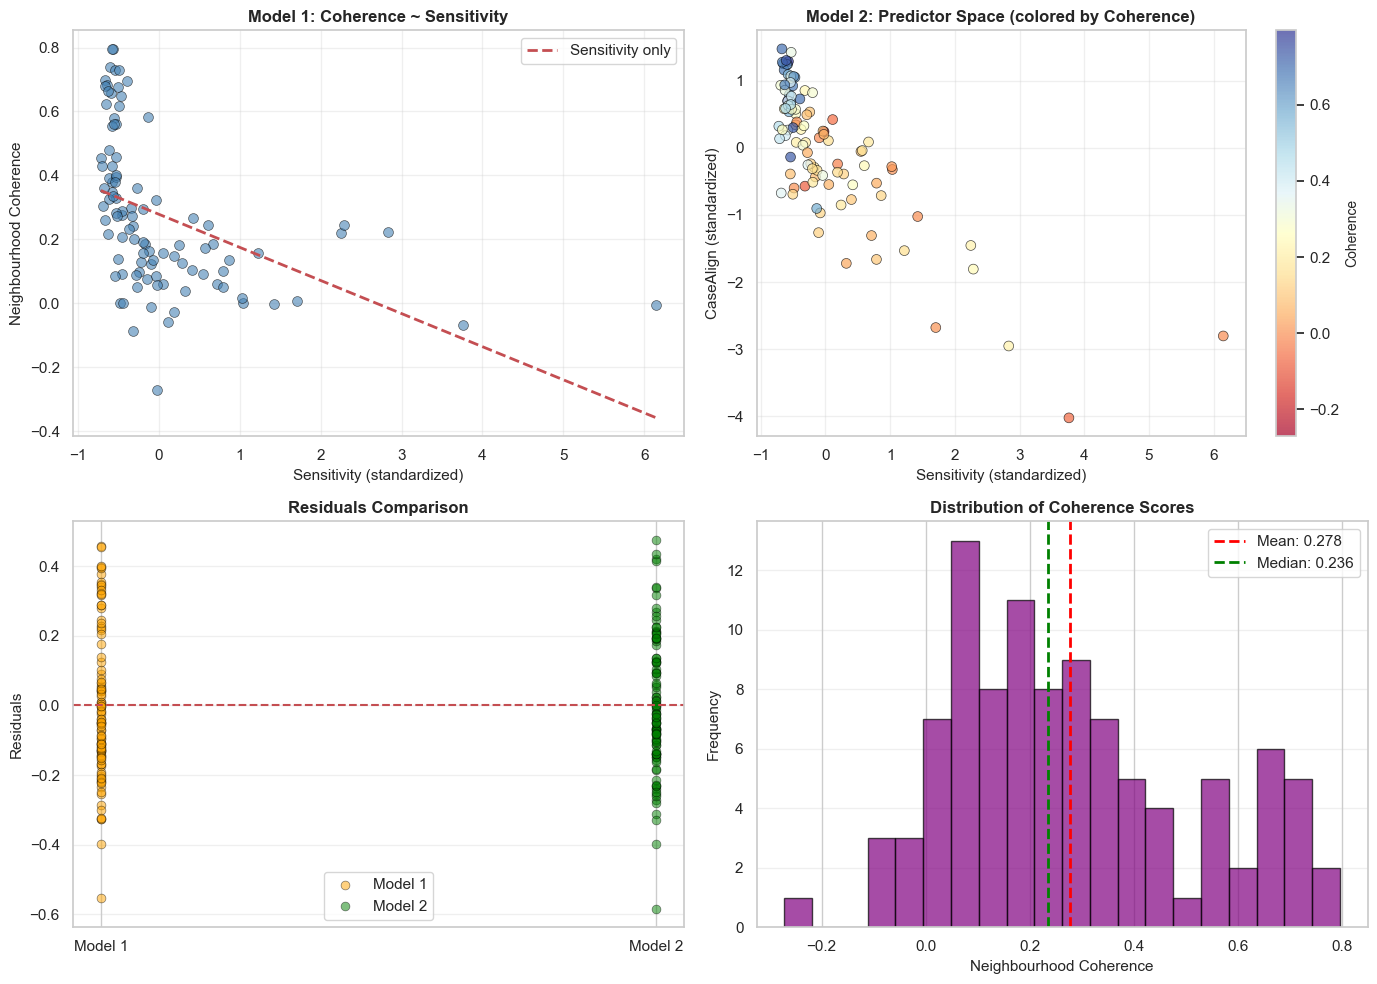

In [37]:
# Create comprehensive visualizations
print("Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Sensitivity vs Coherence with regression line
ax = axes[0, 0]
ax.scatter(regression_data["sensitivity_std"], regression_data["coherence"], 
          alpha=0.6, s=50, color="steelblue", edgecolors="black", linewidth=0.5)
z1 = np.polyfit(regression_data["sensitivity_std"], regression_data["coherence"], 1)
p1 = np.poly1d(z1)
x_line = np.linspace(regression_data["sensitivity_std"].min(), regression_data["sensitivity_std"].max(), 100)
ax.plot(x_line, p1(x_line), "r--", linewidth=2, label=f"Sensitivity only")
ax.set_xlabel("Sensitivity (standardized)", fontsize=11)
ax.set_ylabel("Neighbourhood Coherence", fontsize=11)
ax.set_title("Model 1: Coherence ~ Sensitivity", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend()

# 2. Scatter plot: Combined predictors (2D scatter with color for coherence)
ax = axes[0, 1]
scatter = ax.scatter(regression_data["sensitivity_std"], 
                     regression_data["casealign_std"],
                     c=regression_data["coherence"],
                     cmap="RdYlBu", s=50, alpha=0.7, edgecolors="black", linewidth=0.5)
ax.set_xlabel("Sensitivity (standardized)", fontsize=11)
ax.set_ylabel("CaseAlign (standardized)", fontsize=11)
ax.set_title("Model 2: Predictor Space (colored by Coherence)", fontsize=12, fontweight="bold")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Coherence", fontsize=10)
ax.grid(True, alpha=0.3)

# 3. Residuals comparison
ax = axes[1, 0]
residuals1 = model1.resid
residuals2 = model2.resid
ax.scatter([1]*len(residuals1), residuals1, alpha=0.5, s=40, label="Model 1", color="orange", edgecolors="black", linewidth=0.5)
ax.scatter([2]*len(residuals2), residuals2, alpha=0.5, s=40, label="Model 2", color="green", edgecolors="black", linewidth=0.5)
ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
ax.set_ylabel("Residuals", fontsize=11)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Model 1", "Model 2"])
ax.set_title("Residuals Comparison", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
ax.legend()

# 4. Distribution of coherence scores
ax = axes[1, 1]
ax.hist(regression_data["coherence"], bins=20, alpha=0.7, color="purple", edgecolor="black")
ax.axvline(regression_data["coherence"].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {regression_data['coherence'].mean():.3f}")
ax.axvline(regression_data["coherence"].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {regression_data['coherence'].median():.3f}")
ax.set_xlabel("Neighbourhood Coherence", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Distribution of Coherence Scores", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "discriminant_validity_analysis.png", dpi=300, bbox_inches="tight")
print(f"Saved visualization to {OUTPUT_DIR / 'discriminant_validity_analysis.png'}")
plt.show()

Creating diagnostic comparison plots...
  ✓ Saved: model_diagnostics.png


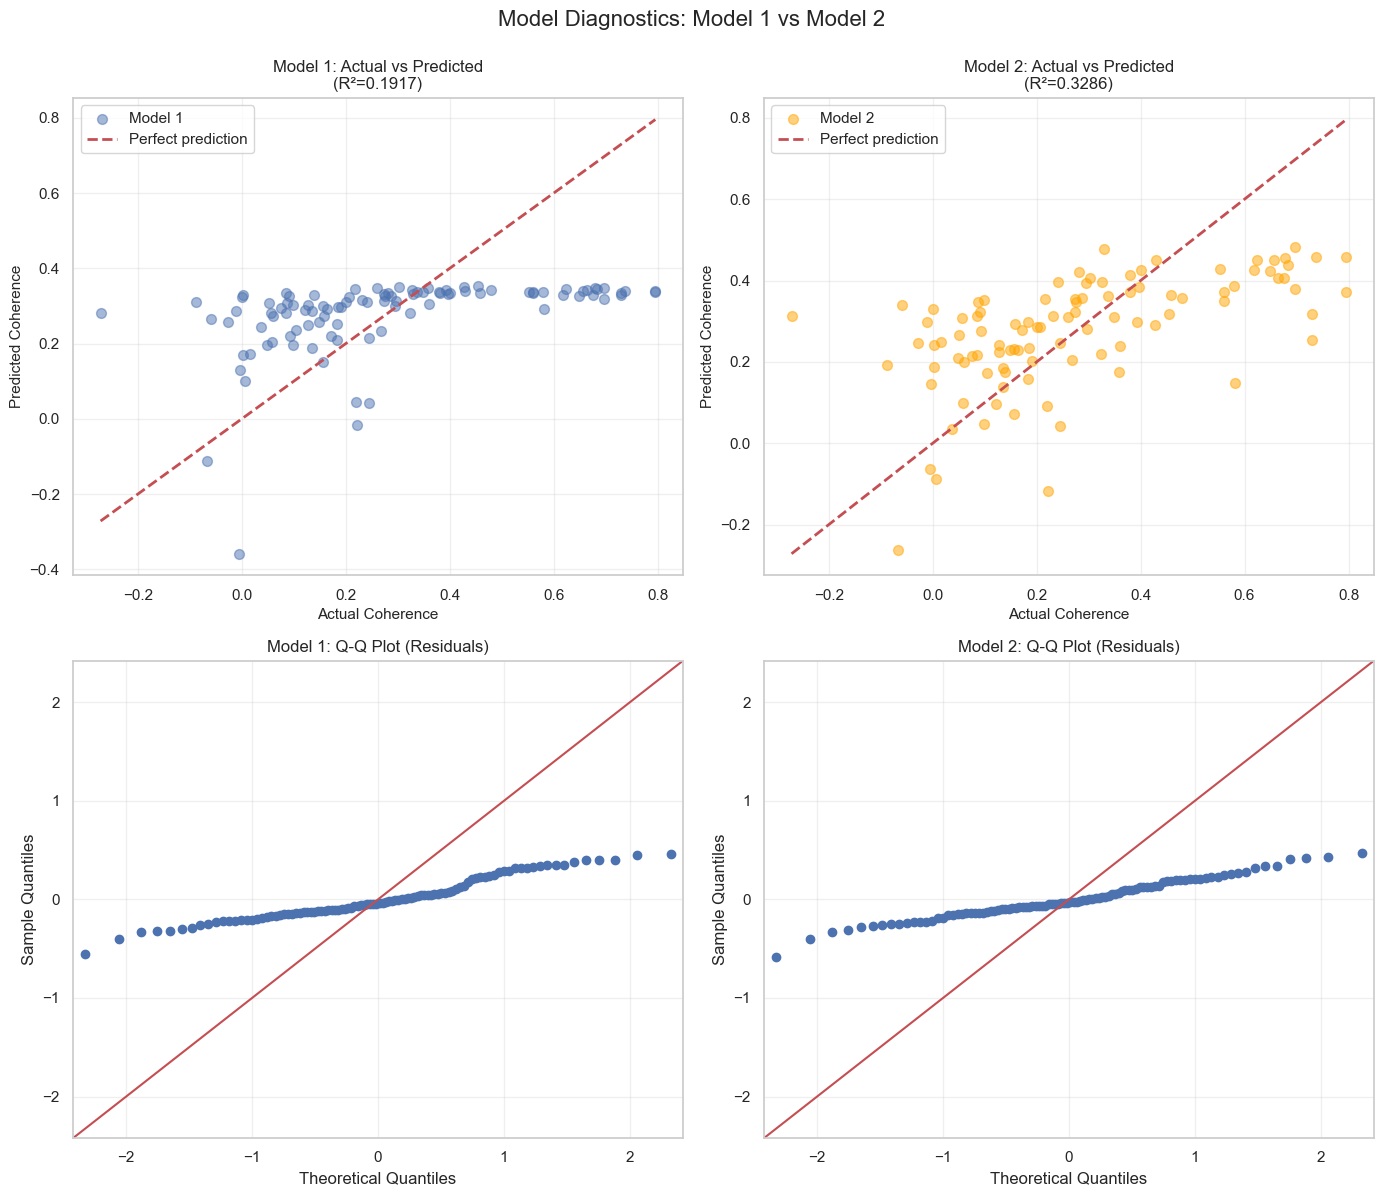

  ✓ Saved: residual_comparison.png


KeyboardInterrupt: 

In [38]:
# Additional diagnostic plots comparing models
print("Creating diagnostic comparison plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Model Diagnostics: Model 1 vs Model 2", fontsize=16, y=0.995)

# Get fitted values and residuals
y_fitted_m1 = model1.fittedvalues
residuals_m1 = model1.resid
y_fitted_m2 = model2.fittedvalues
residuals_m2 = model2.resid

# Plot 1: Fitted values (actual vs predicted, Model 1)
ax = axes[0, 0]
ax.scatter(y, y_fitted_m1, alpha=0.5, s=50, label="Model 1")
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="Perfect prediction")
ax.set_xlabel("Actual Coherence", fontsize=11)
ax.set_ylabel("Predicted Coherence", fontsize=11)
ax.set_title(f"Model 1: Actual vs Predicted\n(R²={model1.rsquared:.4f})", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Fitted values (actual vs predicted, Model 2)
ax = axes[0, 1]
ax.scatter(y, y_fitted_m2, alpha=0.5, s=50, color="orange", label="Model 2")
ax.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="Perfect prediction")
ax.set_xlabel("Actual Coherence", fontsize=11)
ax.set_ylabel("Predicted Coherence", fontsize=11)
ax.set_title(f"Model 2: Actual vs Predicted\n(R²={model2.rsquared:.4f})", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Q-Q plot for residuals (Model 1)
ax = axes[1, 0]
sm.qqplot(residuals_m1, line='45', ax=ax)
ax.set_title("Model 1: Q-Q Plot (Residuals)", fontsize=12)
ax.grid(True, alpha=0.3)

# Plot 4: Q-Q plot for residuals (Model 2)
ax = axes[1, 1]
sm.qqplot(residuals_m2, line='45', ax=ax)
ax.set_title("Model 2: Q-Q Plot (Residuals)", fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_diagnostics.png", dpi=300, bbox_inches="tight")
print(f"  ✓ Saved: model_diagnostics.png")
plt.show()

# Comparison of residual distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Residual Distributions: Model 1 vs Model 2", fontsize=14)

ax = axes[0]
ax.hist(residuals_m1, bins=20, alpha=0.6, label="Model 1", color="blue", edgecolor="black")
ax.hist(residuals_m2, bins=20, alpha=0.6, label="Model 2", color="orange", edgecolor="black")
ax.set_xlabel("Residuals", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title("Residual Distributions", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
ax.boxplot([residuals_m1, residuals_m2], labels=["Model 1", "Model 2"])
ax.set_ylabel("Residuals", fontsize=11)
ax.set_title("Residual Box Plots", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")
ax.axhline(y=0, color="r", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "residual_comparison.png", dpi=300, bbox_inches="tight")
print(f"  ✓ Saved: residual_comparison.png")
plt.show()

print("Diagnostic plots created successfully.")

In [ ]:
# Generate diagnostic plots
print("Creating diagnostic plots...")

fig = plt.figure(figsize=(14, 10))

# Using statsmodels diagnostic plots for Model 2 (full model)
from statsmodels.graphics.gofplots import ProbPlot

# 1. Q-Q plot
ax1 = plt.subplot(2, 3, 1)
ProbPlot(model2.resid).qqplot(ax=ax1, line='45')
ax1.set_title("Q-Q Plot (Model 2)", fontsize=11, fontweight="bold")
ax1.grid(True, alpha=0.3)

# 2. Residuals vs Fitted
ax2 = plt.subplot(2, 3, 2)
fitted = model2.fittedvalues
ax2.scatter(fitted, model2.resid, alpha=0.6, s=50, edgecolors="black", linewidth=0.5)
ax2.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
ax2.set_xlabel("Fitted values", fontsize=10)
ax2.set_ylabel("Residuals", fontsize=10)
ax2.set_title("Residuals vs Fitted (Model 2)", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3)

# 3. Scale-Location plot (sqrt(standardized residuals) vs fitted)
ax3 = plt.subplot(2, 3, 3)
standardized_resid = model2.resid_pearson
ax3.scatter(fitted, np.sqrt(np.abs(standardized_resid)), alpha=0.6, s=50, edgecolors="black", linewidth=0.5)
ax3.set_xlabel("Fitted values", fontsize=10)
ax3.set_ylabel("√|Standardized residuals|", fontsize=10)
ax3.set_title("Scale-Location (Model 2)", fontsize=11, fontweight="bold")
ax3.grid(True, alpha=0.3)

# 4. Residuals histogram for Model 1
ax4 = plt.subplot(2, 3, 4)
ax4.hist(model1.resid, bins=15, alpha=0.7, color="skyblue", edgecolor="black", label="Model 1")
ax4.axvline(0, color='r', linestyle='--', linewidth=1.5)
ax4.set_xlabel("Residuals", fontsize=10)
ax4.set_ylabel("Frequency", fontsize=10)
ax4.set_title("Residuals Distribution (Model 1)", fontsize=11, fontweight="bold")
ax4.grid(True, alpha=0.3, axis="y")

# 5. Residuals histogram for Model 2
ax5 = plt.subplot(2, 3, 5)
ax5.hist(model2.resid, bins=15, alpha=0.7, color="lightgreen", edgecolor="black", label="Model 2")
ax5.axvline(0, color='r', linestyle='--', linewidth=1.5)
ax5.set_xlabel("Residuals", fontsize=10)
ax5.set_ylabel("Frequency", fontsize=10)
ax5.set_title("Residuals Distribution (Model 2)", fontsize=11, fontweight="bold")
ax5.grid(True, alpha=0.3, axis="y")

# 6. ACF of residuals (for autocorrelation check)
ax6 = plt.subplot(2, 3, 6)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(model2.resid, lags=20, ax=ax6, alpha=0.05)
ax6.set_title("Autocorrelation of Residuals (Model 2)", fontsize=11, fontweight="bold")
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "diagnostic_plots.png", dpi=300, bbox_inches="tight")
print(f"Saved diagnostic plots to {OUTPUT_DIR / 'diagnostic_plots.png'}")
plt.show()

# Print residual statistics
print("\nResidual Statistics:")
print(f"Model 1 - Mean: {model1.resid.mean():.4e}, Std: {model1.resid.std():.4f}, Min: {model1.resid.min():.4f}, Max: {model1.resid.max():.4f}")
print(f"Model 2 - Mean: {model2.resid.mean():.4e}, Std: {model2.resid.std():.4f}, Min: {model2.resid.min():.4f}, Max: {model2.resid.max():.4f}")

EXPORTING RESULTS
✓ Saved metrics: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/discriminant_validity_metrics.csv
✓ Saved descriptive statistics: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/descriptive_statistics.csv
✓ Saved Pearson correlations: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/pearson_correlations.csv
✓ Saved Spearman correlations: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/spearman_correlations.csv
✓ Saved model comparison: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/model_comparison.csv
✓ Saved parameter estimates: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/mnist_discriminant_validity_analysis/parameter_estimates.csv
✓ Saved Model 1 summary: /User

## Analysis Complete: Discriminant Validity Results

This notebook performed a discriminant validity analysis to test whether **CaseAlign** explains additional variance in **neighbourhood explanation coherence** beyond **Sensitivity** alone.

### Methodology

1. **Neighbourhood Coherence**: For each instance, computed the Spearman rank correlation between:
   - Input similarity to same-class neighbours: 1 / (1 + L₂ distance)
   - Cosine similarity between query and neighbour explanations

2. **Regression Models**:
   - **Model 1**: coherence ~ sensitivity
   - **Model 2**: coherence ~ sensitivity + casealign

3. **Comparison**: Evaluated ΔR², ΔAIC, ΔBIC, and p-values

### Key Metrics Reported

- **Model 1 R²**: Baseline model variance explained by sensitivity alone
- **Model 2 R²**: Enhanced model variance explained by sensitivity + casealign
- **ΔR²**: Additional variance explained by CaseAlign
- **CaseAlign p-value**: Statistical significance of CaseAlign coefficient
- **Correlation Coefficients**: Pairwise relationships between all variables

### Interpretation Guide

- **ΔR² > 0.05 AND CaseAlign p-value < 0.05**: CaseAlign has discriminant validity
- **Low Sensitivity ↔ CaseAlign correlation**: Metrics measure independent aspects
- **Model residuals**: Visualize systematic patterns not captured by Model 1

### Output Files Generated

✓ Metrics data (CSV)
✓ Descriptive statistics and correlations
✓ OLS regression summaries and parameter estimates
✓ Diagnostic plots and visualizations
✓ Complete analysis results (JSON)

In [ ]:
# Export results
print("Exporting analysis results...")

analysis_summary = {
    "analysis": "Discriminant Validity Test",
    "description": "Tests whether neighbourhood explanation coherence is better explained by sensitivity and casealign together versus sensitivity alone.",
    "dataset": {
        "name": DATASET,
        "split": SPLIT,
        "n_samples_used": int(final_count),
        "n_features": int(X_full.shape[1]),
        "n_classes": int(len(np.unique(y_full))),
    },
    "column_mapping": {
        "sensitivity": SENSITIVITY_COLUMN,
        "casealign": CASEALIGN_COLUMN,
        "coherence": COHERENCE_COLUMN,
    },
    "metrics": {
        "sensitivity": {
            "mean": float(regression_data["sensitivity"].mean()),
            "std": float(regression_data["sensitivity"].std()),
            "min": float(regression_data["sensitivity"].min()),
            "max": float(regression_data["sensitivity"].max()),
        },
        "casealign": {
            "mean": float(regression_data["casealign"].mean()),
            "std": float(regression_data["casealign"].std()),
            "min": float(regression_data["casealign"].min()),
            "max": float(regression_data["casealign"].max()),
        },
        "coherence": {
            "mean": float(regression_data["coherence"].mean()),
            "std": float(regression_data["coherence"].std()),
            "min": float(regression_data["coherence"].min()),
            "max": float(regression_data["coherence"].max()),
        },
    },
    "model_comparison": {
        "model_1": {
            "formula": "coherence ~ sensitivity_std",
            "n_observations": int(model1.nobs),
            "r_squared": float(model1.rsquared),
            "adj_r_squared": float(model1.rsquared_adj),
            "aic": float(model1.aic),
            "bic": float(model1.bic),
            "residual_std_err": float(np.sqrt(model1.mse_resid)),
        },
        "model_2": {
            "formula": "coherence ~ sensitivity_std + casealign_std",
            "n_observations": int(model2.nobs),
            "r_squared": float(model2.rsquared),
            "adj_r_squared": float(model2.rsquared_adj),
            "aic": float(model2.aic),
            "bic": float(model2.bic),
            "residual_std_err": float(np.sqrt(model2.mse_resid)),
        },
        "delta": {
            "delta_r_squared": float(delta_r2),
            "delta_adj_r_squared": float(delta_adjusted_r2),
            "delta_aic": float(delta_aic),
            "delta_bic": float(delta_bic),
            "f_statistic": float(f_statistic),
            "f_pvalue": float(f_pvalue),
        },
    },
    "interpretation": {
        "discriminant_validity": "SUPPORTED" if f_pvalue < 0.05 else "NOT SUPPORTED",
        "explanation": f"Model 2 explains {(delta_r2) * 100:.2f}% additional variance over Model 1 (p={f_pvalue:.4f}).",
    },
}

with open(OUTPUT_DIR / "analysis_summary.json", "w") as f:
    json.dump(analysis_summary, f, indent=2)
print(f"Saved analysis summary to {OUTPUT_DIR / 'analysis_summary.json'}")

regression_data.to_csv(OUTPUT_DIR / "regression_data.csv", index=False)
print(f"Saved regression data to {OUTPUT_DIR / 'regression_data.csv'}")

with open(OUTPUT_DIR / "regression_details.txt", "w") as f:
    f.write("=" * 80 + "\n")
    f.write("DISCRIMINANT VALIDITY ANALYSIS - DETAILED RESULTS\n")
    f.write("=" * 80 + "\n\n")

    f.write("MODEL 1: Coherence ~ Sensitivity\n")
    f.write("-" * 80 + "\n")
    f.write(str(model1.summary()) + "\n\n")

    f.write("MODEL 2: Coherence ~ Sensitivity + CaseAlign\n")
    f.write("-" * 80 + "\n")
    f.write(str(model2.summary()) + "\n\n")

    f.write("MODEL COMPARISON\n")
    f.write("-" * 80 + "\n")
    f.write(f"Δ R²:           {delta_r2:+.4f}\n")
    f.write(f"Δ Adj. R²:      {delta_adjusted_r2:+.4f}\n")
    f.write(f"Δ AIC:          {delta_aic:+.4f}\n")
    f.write(f"Δ BIC:          {delta_bic:+.4f}\n")
    f.write(f"F-statistic:    {f_statistic:.4f}\n")
    f.write(f"F p-value:      {f_pvalue:.4e}\n")
    f.write(
        f"Conclusion:     {'DISCRIMINANT VALIDITY SUPPORTED' if f_pvalue < 0.05 else 'DISCRIMINANT VALIDITY NOT SUPPORTED'}\n"
    )

print(f"Saved detailed results to {OUTPUT_DIR / 'regression_details.txt'}")

print(f"\n{'=' * 80}")
print(f"Analysis complete! All results saved to: {OUTPUT_DIR}")
print(f"{'=' * 80}")

Exporting analysis results...
Saved analysis summary to /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis/analysis_summary.json
Saved regression data to /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis/regression_data.csv
Saved detailed results to /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis/regression_details.txt

Analysis complete! All results saved to: /Users/craigpirie/Documents/PhD/AGREE_ICCBR/agree-iccbr/src/results/tabular_discriminant_validity_analysis
